In [1]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from encoder_pipeline.preprocessor.annotation import AudioFile, Annotation, AnnotationConfig
from encoder_pipeline.preprocessor.spectrogram import (
    STFTConfig, MagConfig, MelConfig, DbConfig, PcenConfig, SpectrogramConfig, Spectrogram,
)

f = "/home/noah/research/experiments/exp_0_reproduce_k_palmer_2026_results/annotations_w_calltype.csv"
df = pd.read_csv(f, low_memory=False)
for col in ["FileBeginSec", "FileEndSec", "Duration", "CenterTime"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df[df["Labels"] == "SRKW"]

N_MELS = 128
stft_config = STFTConfig(n_fft=2048, hop_length=256, center=False)
annotation_config = AnnotationConfig(time_offset=2.5)

# Three SpectrogramConfigs, each picking a different point in the
# freq_scale (mag/mel) x dynamic (db/pcen) space -- same STFT underneath.
mag_db_config = SpectrogramConfig(
    stft=stft_config, freq_scale="mag", mag=MagConfig(),
    dynamic="db", db=DbConfig(ref=1),
)
mel_db_config = SpectrogramConfig(
    stft=stft_config, freq_scale="mel", mel=MelConfig(n_mels=N_MELS),
    dynamic="db", db=DbConfig(ref=1),
)
mel_pcen_config = SpectrogramConfig(
    stft=stft_config, freq_scale="mel", mel=MelConfig(n_mels=N_MELS),
    dynamic="pcen", pcen=PcenConfig(),
)

row = df.iloc[0]
audio_file = AudioFile(row["LocalPath"])
a = Annotation(audio_file, row["Labels"], row["FileBeginSec"], row["Duration"], annotation_config)

mag_spec = Spectrogram(mag_db_config)
mag_output = mag_spec.compute_magnitude(a)
mag_db = mag_spec.apply_dynamic(a, mag_output)

mel_db_spec = Spectrogram(mel_db_config)
mel_output = mel_db_spec.compute_mel(a)
mel_db = mel_db_spec.apply_dynamic(a, mel_output)

mel_pcen_spec = Spectrogram(mel_pcen_config)
mel_pcen_output = mel_pcen_spec.compute_mel(a)
mel_pcen = mel_pcen_spec.apply_dynamic(a, mel_pcen_output)

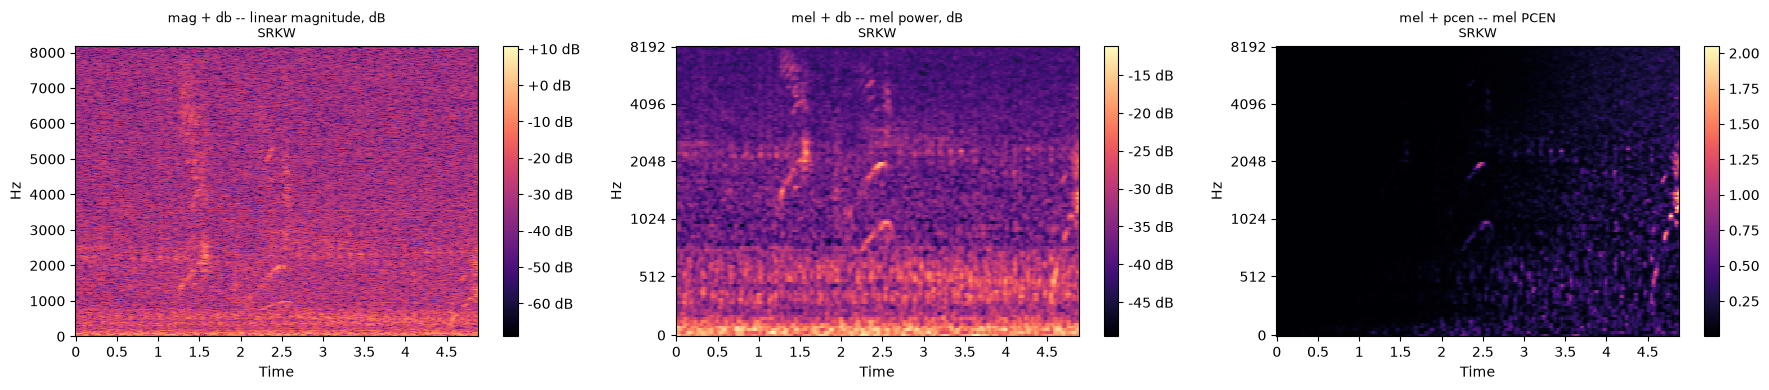

In [2]:
# mag_db/mel_db/mel_pcen are computed above in cell 1 -- view all three
# side by side. Each panel already has its dynamic-range compression baked
# in via apply_dynamic(), driven entirely by its SpectrogramConfig
# (freq_scale + dynamic + the matching sub-config).
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

img0 = librosa.display.specshow(
    mag_db, sr=a.sr, hop_length=stft_config.hop_length,
    x_axis="time", y_axis="linear", cmap="magma", ax=axes[0],
)
axes[0].set_title(f"mag + db -- linear magnitude, dB\n{a.label}", fontsize=9)
fig.colorbar(img0, ax=axes[0], format="%+2.0f dB")

img1 = librosa.display.specshow(
    mel_db, sr=a.sr, hop_length=stft_config.hop_length,
    x_axis="time", y_axis="mel", cmap="magma", ax=axes[1],
)
axes[1].set_title(f"mel + db -- mel power, dB\n{a.label}", fontsize=9)
fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

img2 = librosa.display.specshow(
    mel_pcen, sr=a.sr, hop_length=stft_config.hop_length,
    x_axis="time", y_axis="mel", cmap="magma", ax=axes[2],
)
axes[2].set_title(f"mel + pcen -- mel PCEN\n{a.label}", fontsize=9)
fig.colorbar(img2, ax=axes[2])

fig.tight_layout()
plt.show()

In [3]:
from pathlib import Path

from encoder_pipeline.common.config import load_yaml_config, PipelineConfig
from encoder_pipeline.preprocessor.dataset import Dataset

config = load_yaml_config(Path("../configs/base.yaml"), PipelineConfig)

dataset = Dataset(config.preprocessor.spectrogram, config.preprocessor.annotation, config.preprocessor.dataset)
dataset.df = dataset.df[dataset.df["Labels"] == "SRKW"]

# Take just the first 10 unique files' worth of annotations, to exercise
# Dataset.build_hdf5's read-file-once -> spectrogram -> single-writer HDF5
# pipeline without processing the whole df.
sample_files = dataset.df["LocalPath"].unique()[:10]
dataset.df = dataset.df[dataset.df["LocalPath"].isin(sample_files)].copy()

dataset.build_hdf5()

/home/noah/perch_venv/lib/python3.11/site-packages/librosa/feature/spectral.py:2148: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
